# XGBoost for Chest X-Ray Classification
## Step 1 — Imports

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

## Step 2 — Configuration

In [2]:
IMG_SIZE     = 128
N_COMPONENTS = 150   

train_path = '/home/vineet/Downloads/XGBoost/chest-xray/train'
test_path  = '/home/vineet/Downloads/XGBoost/chest-xray/test'

## Step 3 — Data Loading Function

In [3]:
def load_data(path):
    X = []
    y = []

    classes = os.listdir(path)

    for label in classes:
        folder = os.path.join(path, label)

        if not os.path.isdir(folder):
            continue

        print(f"Loading class: {label}")

        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            img = cv2.imread(img_path)

            if img is None:
                continue

            # Resize image
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            # Normalize pixel values
            img = img / 255.0

            # Flatten to 1-D feature vector
            img = img.flatten()

            X.append(img)
            y.append(label)

    return np.array(X), np.array(y)

## Step 4 — Load Data

In [4]:
X_train, y_train = load_data(train_path)
X_test,  y_test  = load_data(test_path)

print("Training data shape:", X_train.shape)
print("Testing data shape: ", X_test.shape)

Loading class: NORMAL
Loading class: PNEUMONIA
Loading class: NORMAL
Loading class: PNEUMONIA
Training data shape: (5216, 49152)
Testing data shape:  (624, 49152)


## Step 5 — Label Encoding

In [5]:
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded  = le.transform(y_test)

print("Classes:", le.classes_)

Classes: ['NORMAL' 'PNEUMONIA']


## Step 6 — PCA Dimensionality Reduction

In [6]:
# Fit PCA on training data only, then apply to both sets
pca = PCA(n_components=N_COMPONENTS, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca  = pca.transform(X_test)

explained_var = pca.explained_variance_ratio_.sum() * 100

print(f"Original feature size : {X_train.shape[1]:,}")
print(f"Reduced feature size  : {X_train_pca.shape[1]}")
print(f"Variance retained     : {explained_var:.2f}%")

Original feature size : 49,152
Reduced feature size  : 150
Variance retained     : 88.52%


## Step 7 — Train Model

In [7]:
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=4,
    n_estimators=100,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train_pca, y_train_encoded)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


## Step 8 — Evaluation Metrics

In [8]:
y_pred = model.predict(X_test_pca)

accuracy  = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='weighted')
recall    = recall_score(y_test_encoded, y_pred, average='weighted')
f1        = f1_score(y_test_encoded, y_pred, average='weighted')

print("=========== TEST METRICS ===========")
print(f"Accuracy : {accuracy  * 100:.2f}%")
print(f"Precision: {precision * 100:.2f}%")
print(f"Recall   : {recall    * 100:.2f}%")
print(f"F1 Score : {f1        * 100:.2f}%")

print("\n=========== CLASSIFICATION REPORT ===========")
print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

=========== TEST METRICS ===========
Accuracy : 76.44%
Precision: 81.53%
Recall   : 76.44%
F1 Score : 73.25%

=========== CLASSIFICATION REPORT ===========
              precision    recall  f1-score   support

      NORMAL       0.96      0.39      0.55       234
   PNEUMONIA       0.73      0.99      0.84       390

    accuracy                           0.76       624
   macro avg       0.84      0.69      0.70       624
weighted avg       0.82      0.76      0.73       624



## Step 9 — Accuracy vs Training Data Percentage

In [9]:
percentages = [0.2, 0.4, 0.6, 0.8]
xgb_acc = []

for p in percentages:
    X_subset, _, y_subset, _ = train_test_split(
        X_train_pca,
        y_train_encoded,
        train_size=p,
        stratify=y_train_encoded,
        random_state=42
    )

    m = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1
    )
    m.fit(X_subset, y_subset)

    acc = accuracy_score(y_test_encoded, m.predict(X_test_pca))
    xgb_acc.append(acc * 100)

    print(f"{int(p * 100)}% training data  →  Accuracy = {acc * 100:.2f}%")

print("\nAccuracy list:", xgb_acc)

20% training data  →  Accuracy = 75.16%
40% training data  →  Accuracy = 74.36%
60% training data  →  Accuracy = 75.00%
80% training data  →  Accuracy = 75.80%

Accuracy list: [75.16025641025641, 74.35897435897436, 75.0, 75.80128205128204]


## Step 10 — Visualisation: Confusion Matrix

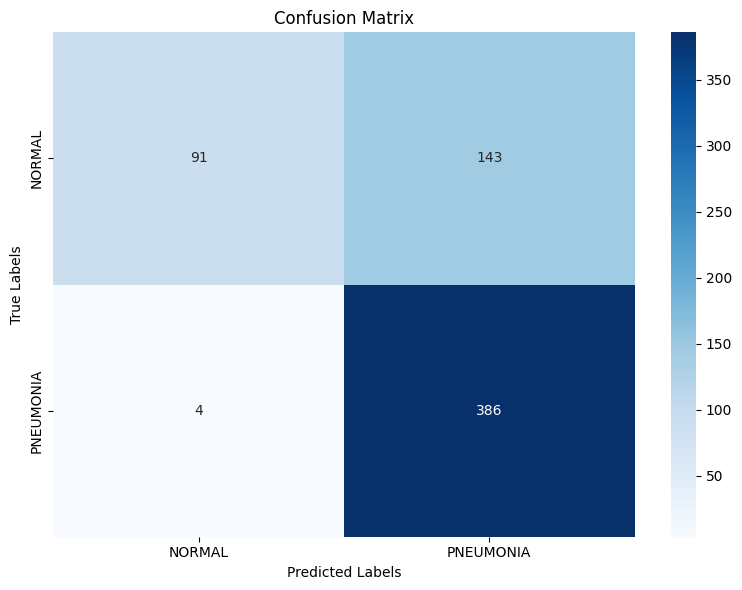

In [10]:
cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

## Step 11 — Visualisation: Training vs Validation Loss per Data Percentage

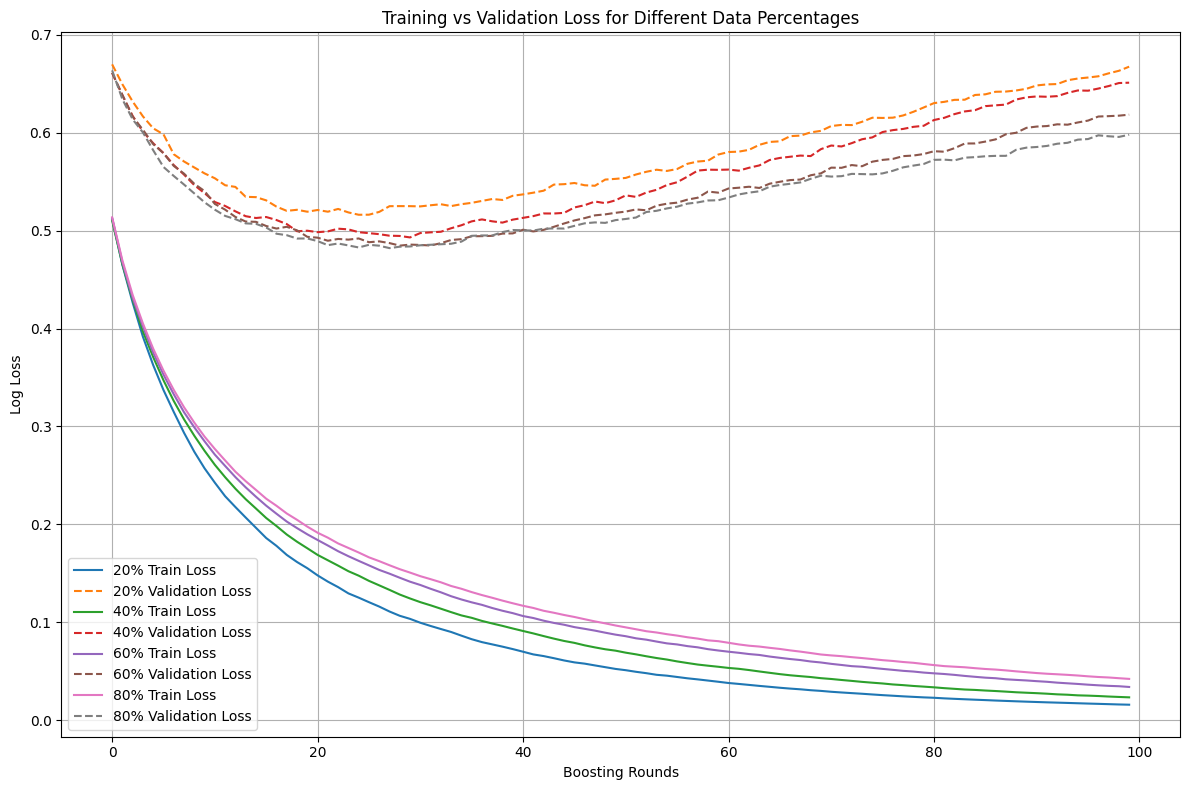

In [11]:
plt.figure(figsize=(12, 8))

for p in percentages:
    X_subset, _, y_subset, _ = train_test_split(
        X_train_pca,
        y_train_encoded,
        train_size=p,
        stratify=y_train_encoded,
        random_state=42
    )

    m = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        max_depth=4,
        n_estimators=100,
        learning_rate=0.1
    )

    eval_set = [
        (X_subset,   y_subset),
        (X_test_pca, y_test_encoded)
    ]

    m.fit(X_subset, y_subset, eval_set=eval_set, verbose=False)

    results   = m.evals_result()
    train_loss = results['validation_0']['logloss']
    val_loss   = results['validation_1']['logloss']

    plt.plot(train_loss,              label=f'{int(p * 100)}% Train Loss')
    plt.plot(val_loss, linestyle='--', label=f'{int(p * 100)}% Validation Loss')

plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss for Different Data Percentages')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()